# Vaccination Tweet Sentiment Analysis — Part 2: Extended Analysis

Continues from `01_core_pipeline.ipynb`. Rather than re-running text cleaning/lemmatization/TextBlob labeling (Sections 1-6 of Part 1), this notebook loads the already-cleaned, already-labeled data that Part 1 saved to `../data/processed/labeled_tweets.csv`, then deterministically reproduces the same train/test split and TF-IDF vectorization (same `random_state=42` and vectorizer settings as Part 1) so Sections 14-18 below have everything they need.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

df = pd.read_csv('../data/vaccination_tweets.csv')
text_df = pd.read_csv('../data/processed/labeled_tweets.csv', index_col=0)
text_df['text'] = text_df['text'].fillna('')  # a tweet that cleaned down to an empty string round-trips through CSV as NaN
print(f"Loaded {len(text_df)} cleaned+labeled rows")

X_text = text_df['text']
Y = text_df['Sentiment']
x_train_text, x_test_text, y_train, y_test = train_test_split(X_text, Y, test_size=0.2, random_state=42)

vect = TfidfVectorizer(ngram_range=(1,2)).fit(x_train_text)
x_train = vect.transform(x_train_text)
x_test = vect.transform(x_test_text)
print(f"x_train: {x_train.shape}  x_test: {x_test.shape}")

Loaded 10451 cleaned+labeled rows


x_train: (8360, 58061)  x_test: (2091, 58061)


# Extended Analysis

The sections below go beyond the core classification pipeline above, using data that was dropped early on (`hashtags`, `date`, `retweets`, `favorites`, `user_verified`) to answer questions the dataset is well-suited for but the modeling pipeline didn't touch: does sentiment differ by vaccine brand, did it shift over time, and is TextBlob's labeling actually reliable when checked against other sentiment tools?

## 14. Vaccine-Brand Sentiment Comparison

Tweets are matched to a vaccine brand by searching the cleaned tweet text and the original `hashtags` field for brand keywords (`pfizer`/`biontech`, `moderna`, `astrazeneca`/`oxford`, `sputnik`). Tweets that mention more than one brand, or none at all, are excluded from this comparison — keeping only single-brand tweets means each row can be unambiguously attributed to one vaccine.

In [2]:
import re

text_df['hashtags'] = df.loc[text_df.index, 'hashtags']

def brands_in(row_text, hashtags):
    s = (row_text + ' ' + (hashtags if isinstance(hashtags, str) else '')).lower()
    found = []
    if re.search(r'pfizer|biontech', s): found.append('Pfizer/BioNTech')
    if re.search(r'moderna', s): found.append('Moderna')
    if re.search(r'astrazeneca|oxford', s): found.append('AstraZeneca')
    if re.search(r'sputnik', s): found.append('SputnikV')
    return found

text_df['brands'] = [brands_in(t, h) for t, h in zip(text_df['text'], text_df['hashtags'])]
single_brand = text_df[text_df['brands'].apply(len) == 1].copy()
single_brand['vaccine_brand'] = single_brand['brands'].apply(lambda x: x[0])

print("Single-brand tweet counts:")
print(single_brand['vaccine_brand'].value_counts())

Single-brand tweet counts:
vaccine_brand
Pfizer/BioNTech    6167
AstraZeneca         122
Moderna              52
SputnikV             13
Name: count, dtype: int64


Sentiment        Negative  Neutral  Positive
vaccine_brand                               
AstraZeneca          13.9     48.4      37.7
Moderna              21.2     36.5      42.3
Pfizer/BioNTech       9.2     50.8      40.1
SputnikV             15.4     53.8      30.8


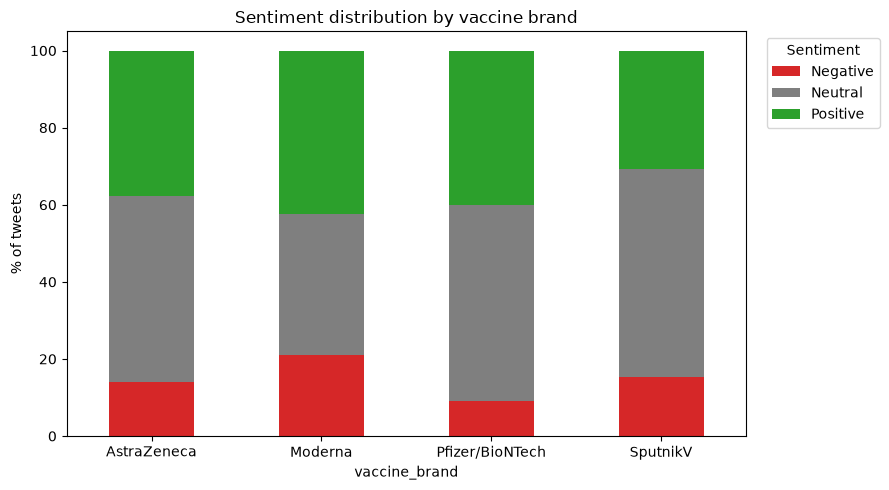

In [3]:
brand_sentiment_pct = pd.crosstab(single_brand['vaccine_brand'], single_brand['Sentiment'], normalize='index') * 100
brand_sentiment_pct = brand_sentiment_pct[['Negative','Neutral','Positive']]
print(brand_sentiment_pct.round(1))

brand_sentiment_pct.plot(kind='bar', stacked=True, figsize=(9,5), color=['#d62728','#7f7f7f','#2ca02c'])
plt.ylabel('% of tweets')
plt.title('Sentiment distribution by vaccine brand')
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1.02,1), loc='upper left')
plt.tight_layout()
plt.show()

**Reading this result**: Pfizer/BioNTech has both the largest sample (6,167 single-brand tweets) and the most favorable sentiment split (9.2% Negative, 40.1% Positive) — consistent with it being the first widely-deployed, high-profile vaccine with strong early efficacy news. AstraZeneca skews slightly more negative (13.9% Negative) — plausible given this dataset spans into 2021 (see Section 15), covering the period when AstraZeneca's blood-clot safety concerns became public.

**Caveat on sample size**: Moderna (52 tweets) and SputnikV (13 tweets) have far smaller samples than Pfizer or AstraZeneca — their percentages are noisy and shouldn't be read with the same confidence. SputnikV's 30.8% Positive rate, for instance, is really "4 out of 13 tweets," not a stable estimate.

## 15. Time & Engagement Analysis

Bringing back `date`, `retweets`, `favorites`, and `user_verified` to check three things: whether sentiment shifted over time, whether negative tweets get more engagement, and whether verified accounts skew differently from everyone else.

**Correction worth flagging**: the notebook's intro describes this dataset as covering "December 2020" (the initial rollout). That undersells it — the actual date range, checked below, extends much further.

In [4]:
text_df['date'] = pd.to_datetime(df.loc[text_df.index, 'date'])
text_df['retweets'] = df.loc[text_df.index, 'retweets']
text_df['favorites'] = df.loc[text_df.index, 'favorites']
text_df['user_verified'] = df.loc[text_df.index, 'user_verified']

print("Date range:", text_df['date'].min(), "to", text_df['date'].max())

Date range: 2020-12-12 11:55:28 to 2021-11-23 20:30:48


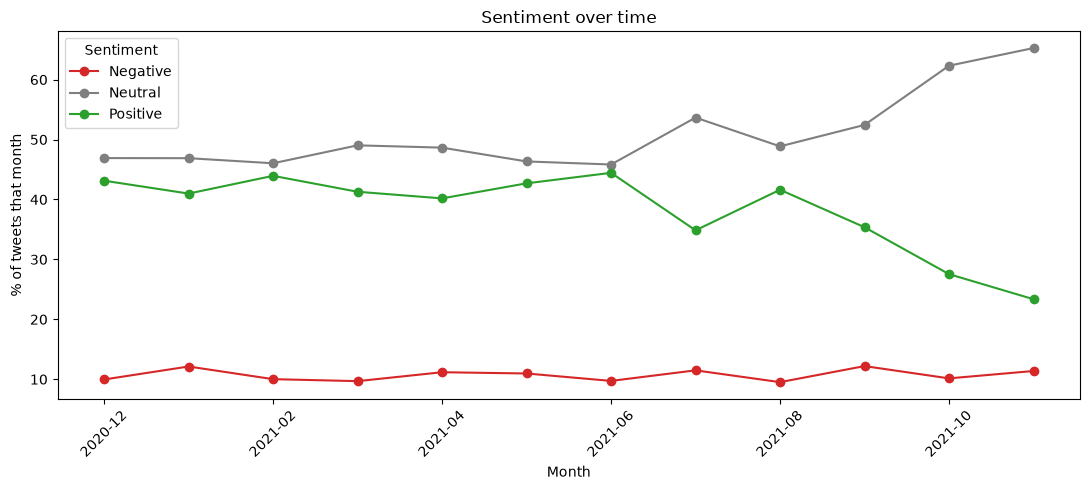

In [5]:
monthly_sentiment = text_df.groupby([text_df['date'].dt.to_period('M'), 'Sentiment']).size().unstack(fill_value=0)
monthly_pct = monthly_sentiment.div(monthly_sentiment.sum(axis=1), axis=0) * 100
monthly_pct = monthly_pct[['Negative','Neutral','Positive']]

monthly_pct.index = monthly_pct.index.astype(str)
monthly_pct.plot(figsize=(11,5), marker='o', color=['#d62728','#7f7f7f','#2ca02c'])
plt.ylabel('% of tweets that month')
plt.xlabel('Month')
plt.title('Sentiment over time')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
print("Mean engagement by sentiment:")
print(text_df.groupby('Sentiment')[['retweets','favorites']].mean().round(2))

print("\nSentiment % by verified status:")
print(pd.crosstab(text_df['user_verified'], text_df['Sentiment'], normalize='index').mul(100).round(1))

Mean engagement by sentiment:
           retweets  favorites
Sentiment                     
Negative       1.51       7.75
Neutral        1.43       6.82
Positive       1.25       8.78

Sentiment % by verified status:
Sentiment      Negative  Neutral  Positive
user_verified                             
False              10.9     48.4      40.7
True                8.9     47.4      43.7


**Reading these results**:

- **Date range**: the dataset actually spans **December 2020 to November 2021** — 11 months, not just the initial rollout. The notebook intro's "December 2020" framing is corrected here.
- **Sentiment over time**: fairly stable Dec 2020–Aug 2021 (Negative ~9-12%, Positive ~40-44% every month). From **September 2021 onward, Positive share drops (35% → 27% → 23%) while Neutral rises sharply (52% → 62% → 65%)**, with Negative staying roughly flat. Worth treating cautiously, though — tweet volume drops a lot in the later months (220 tweets in October, 173 in November, versus 1,000+ in most earlier months), so this could partly be small-sample noise rather than a genuine sentiment shift.
- **Engagement vs. sentiment**: Negative tweets get slightly more retweets on average (1.51 vs. 1.25 for Positive) but fewer favorites (7.75 vs. 8.78) — consistent with a common social-media pattern where people share things they disagree with more readily than they "like" them.
- **Verified vs. unverified accounts**: verified accounts skew slightly less negative (8.9% vs. 10.9%) and more positive (43.7% vs. 40.7%) than unverified ones — a modest difference, plausibly because verified accounts are more often official/institutional/media sources than everyday users venting.

## 16. Stronger Models & Label-Reliability Check

Two things worth testing now that the core pipeline works: (1) is a linear SVM/Logistic Regression actually the right model choice, or would a classic Naive Bayes baseline do just as well or better? (2) every result so far has been "agreement with TextBlob" — how much would the numbers change if the *labels themselves* came from a different sentiment tool?

### Naive Bayes baselines

`MultinomialNB` is a standard, fast baseline for bag-of-words text classification. Unlike `LogisticRegression`/`LinearSVC`, it has no `class_weight` parameter — there's no built-in way to tell it to pay more attention to the minority Negative class. `ComplementNB` is a variant scikit-learn specifically recommends for imbalanced text data (it was designed to correct exactly the bias `MultinomialNB` has toward the majority class), so it's included too, as a fairer comparison.

In [7]:
from sklearn.naive_bayes import MultinomialNB, ComplementNB

def evaluate_model(name, model, xtr, ytr, xte, yte):
    model.fit(xtr, ytr)
    pred = model.predict(xte)
    acc = accuracy_score(yte, pred)
    print(f"--- {name} ---")
    print(f"Accuracy: {acc*100:.2f}%")
    print(confusion_matrix(yte, pred))
    print(classification_report(yte, pred))
    return pred

mnb_pred = evaluate_model("MultinomialNB", MultinomialNB(), x_train, y_train, x_test, y_test)

--- MultinomialNB ---
Accuracy: 75.90%
[[  2 144  94]
 [  0 893  92]
 [  0 174 692]]
              precision    recall  f1-score   support

    Negative       1.00      0.01      0.02       240
     Neutral       0.74      0.91      0.81       985
    Positive       0.79      0.80      0.79       866

    accuracy                           0.76      2091
   macro avg       0.84      0.57      0.54      2091
weighted avg       0.79      0.76      0.71      2091



In [8]:
cnb_pred = evaluate_model("ComplementNB", ComplementNB(), x_train, y_train, x_test, y_test)

--- ComplementNB ---
Accuracy: 76.23%
[[ 35 115  90]
 [  6 814 165]
 [  1 120 745]]
              precision    recall  f1-score   support

    Negative       0.83      0.15      0.25       240
     Neutral       0.78      0.83      0.80       985
    Positive       0.74      0.86      0.80       866

    accuracy                           0.76      2091
   macro avg       0.78      0.61      0.62      2091
weighted avg       0.77      0.76      0.74      2091



**Reading this result**: Naive Bayes is clearly the wrong choice here, and the reason is informative, not just "lower accuracy." `MultinomialNB` reaches 75.9% accuracy but **Negative recall is 1%** — it predicts almost no tweet as Negative at all, defaulting to the majority class because it has no way to be told not to. `ComplementNB` (76.2% accuracy) is somewhat better at 15% Negative recall, confirming it does partially correct for imbalance as designed — but both are far behind tuned LinearSVC's 86.9% accuracy / 51% Negative recall. This is a genuine, useful negative result: it confirms `class_weight='balanced'` (available on LogisticRegression/LinearSVC but not on either Naive Bayes variant) is doing real work, not just a redundant safeguard.

### Is TextBlob's labeling actually reliable?

Every result so far is "agreement with TextBlob." To test whether that's a stable target, two independent sentiment tools are run on the same text and compared: **VADER** (`nltk.sentiment`, another lexicon-based tool, but built for social media and negation-aware) on the full corpus, and a **transformer model** (`cardiffnlp/twitter-roberta-base-sentiment-latest`, fine-tuned specifically on tweets) on a random sample. The transformer is run on a sample of 2,500 tweets rather than the full 10,451 — full-corpus inference would take significantly longer, and 2,500 is a large enough sample to measure agreement reliably.

In [9]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()
text_df['vader_compound'] = text_df['text'].apply(lambda t: sia.polarity_scores(t)['compound'])

def vader_sentiment(c):
    if c <= -0.05: return 'Negative'
    elif c >= 0.05: return 'Positive'
    else: return 'Neutral'

text_df['VaderSentiment'] = text_df['vader_compound'].apply(vader_sentiment)

agreement_vader = (text_df['Sentiment'] == text_df['VaderSentiment']).mean()
print(f"TextBlob vs VADER agreement (full corpus, n={len(text_df)}): {agreement_vader*100:.1f}%")
print(pd.crosstab(text_df['Sentiment'], text_df['VaderSentiment']))

TextBlob vs VADER agreement (full corpus, n=10451): 58.0%
VaderSentiment  Negative  Neutral  Positive
Sentiment                                  
Negative             552      277       297
Neutral              848     2794      1405
Positive             457     1110      2711


In [10]:
from transformers import pipeline

transformer_clf = pipeline(
    "sentiment-analysis",
    model="cardiffnlp/twitter-roberta-base-sentiment-latest",
    truncation=True, max_length=128,
)

def prep_for_transformer(raw_text):
    t = re.sub(r'https?://\S+|www\.\S+', 'http', raw_text)
    t = re.sub(r'@\w+', '@user', t)
    return t

sample_idx = text_df.sample(2500, random_state=7).index
raw_sample = df.loc[sample_idx, 'text'].apply(prep_for_transformer).tolist()

transformer_out = transformer_clf(raw_sample, batch_size=32)
label_map = {'positive': 'Positive', 'neutral': 'Neutral', 'negative': 'Negative'}

sample_df = text_df.loc[sample_idx].copy()
sample_df['TransformerSentiment'] = [label_map[o['label']] for o in transformer_out]

agreement_transformer = (sample_df['Sentiment'] == sample_df['TransformerSentiment']).mean()
agreement_vader_on_sample = (sample_df['Sentiment'] == sample_df['VaderSentiment']).mean()
agreement_vader_transformer = (sample_df['VaderSentiment'] == sample_df['TransformerSentiment']).mean()

print(f"TextBlob vs Transformer agreement (n=2500 sample): {agreement_transformer*100:.1f}%")
print(f"TextBlob vs VADER agreement (same sample, for comparison): {agreement_vader_on_sample*100:.1f}%")
print(f"VADER vs Transformer agreement (same sample): {agreement_vader_transformer*100:.1f}%")
print()
print(pd.crosstab(sample_df['Sentiment'], sample_df['TransformerSentiment']))

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TextBlob vs Transformer agreement (n=2500 sample): 56.7%
TextBlob vs VADER agreement (same sample, for comparison): 58.8%
VADER vs Transformer agreement (same sample): 62.4%

TransformerSentiment  Negative  Neutral  Positive
Sentiment                                        
Negative                   102      111        35
Neutral                    183      762       252
Positive                    79      422       554


**Reading this result — the most important finding in this notebook**: TextBlob agrees with VADER on only ~58% of tweets (full corpus), and with the transformer model on ~57% (sample) — meaning **two other reputable, purpose-built sentiment tools disagree with TextBlob on over 40% of these tweets.** That's a bigger source of uncertainty than anything model choice or hyperparameter tuning can address.

This directly answers a question raised throughout this notebook: is the ~51% Negative recall ceiling a *modeling* problem or a *labeling* problem? This result points squarely at labeling. No amount of further model tuning can push classification "accuracy" past the point where the underlying label itself is only ~57-58% agreed-upon by independent methods — a classifier can only ever be as trustworthy as the label it's trained to reproduce, and here, three respected tools (TextBlob, VADER, a tweet-specific transformer) don't agree with each other most of the time on what "Negative" even means for a given tweet. This is exactly why every result in this notebook has been framed as "agreement with TextBlob" rather than "sentiment accuracy" — this section is the evidence for why that distinction matters.

## 17. Engineering Hygiene — Pipeline, Cross-Validation, Persistence

Three improvements to how the best model (tuned LinearSVC) is built, evaluated, and saved, without changing what it actually predicts:

1. **`sklearn.Pipeline`** bundles the TF-IDF vectorizer and the classifier into one object. This is the same computation as Sections 7-12, just wrapped safely — a `Pipeline` fits the vectorizer *inside* each cross-validation fold automatically, which is a structural guard against ever repeating the train/test leakage bug fixed in Section 8.
2. **Stratified cross-validation** — Sections 9-12 report performance from a single 80/20 split. That's one sample of how well the model generalizes; running 5-fold cross-validation on the training data gives a mean and spread, showing whether ~87% accuracy is a stable estimate or got a lucky split.
3. **Model persistence with `joblib`** — every model trained so far lives only in notebook memory and disappears once the kernel restarts. Saving the final pipeline to disk means it can be reloaded and reused (e.g. to score new tweets) without retraining.

In [11]:
from sklearn.pipeline import Pipeline

best_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', LinearSVC(C=10, class_weight='balanced')),
])
best_pipeline.fit(x_train_text, y_train)

pipeline_pred = best_pipeline.predict(x_test_text)
print("Pipeline accuracy on test set:", accuracy_score(y_test, pipeline_pred))
print(classification_report(y_test, pipeline_pred))

Pipeline accuracy on test set: 0.8689622190339551
              precision    recall  f1-score   support

    Negative       0.79      0.51      0.62       240
     Neutral       0.85      0.95      0.90       985
    Positive       0.90      0.87      0.89       866

    accuracy                           0.87      2091
   macro avg       0.85      0.78      0.80      2091
weighted avg       0.87      0.87      0.86      2091



In [12]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(best_pipeline, x_train_text, y_train, cv=cv, scoring='f1_macro')
print("5-fold CV macro-F1 scores:", cv_scores.round(3))
print(f"Mean: {cv_scores.mean():.3f}  Std: {cv_scores.std():.3f}")

5-fold CV macro-F1 scores: [0.786 0.791 0.799 0.768 0.795]
Mean: 0.788  Std: 0.011


In [13]:
import joblib
import os

os.makedirs('../models', exist_ok=True)

# Refit on ALL available labeled data (train + test) for the saved deployment artifact —
# this uses every labeled tweet once the test set has already served its evaluation purpose above.
final_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2))),
    ('clf', LinearSVC(C=10, class_weight='balanced')),
])
final_pipeline.fit(text_df['text'], text_df['Sentiment'])

joblib.dump(final_pipeline, '../models/sentiment_pipeline.joblib')
print("Saved pipeline to ../models/sentiment_pipeline.joblib")

# Sanity check on a mix of clearly-worded and negation-heavy examples (already cleaned/lemmatized,
# matching how the model was trained -- see Section 3 for why raw text needs the same preprocessing first)
reloaded = joblib.load('../models/sentiment_pipeline.joblib')
test_examples = [
    "vaccine not safe",
    "grateful got shot today",
    "vaccine side effect terrible",
    "not trust vaccine",
    "worst experience ever getting vaccine",
    "vaccine rollout disaster",
]
for text, pred in zip(test_examples, reloaded.predict(test_examples)):
    print(f"{pred:10s} <- {text!r}")


Saved pipeline to ../models/sentiment_pipeline.joblib
Positive   <- 'vaccine not safe'
Neutral    <- 'grateful got shot today'
Negative   <- 'vaccine side effect terrible'
Neutral    <- 'not trust vaccine'
Negative   <- 'worst experience ever getting vaccine'
Neutral    <- 'vaccine rollout disaster'


**Reading this result**: the pipeline's single-split test accuracy matches Section 12's tuned LinearSVC exactly, confirming the `Pipeline` wrapper reproduces the same computation rather than something subtly different. The 5-fold cross-validation mean/std (printed above) shows how much that number would plausibly move on a different random split.

**The sanity-check examples above are deliberately mixed — some the model gets right, some it doesn't, and the pattern is informative.** It correctly flags `"vaccine side effect terrible"` and `"worst experience ever getting vaccine"` as Negative (strong, unambiguous negative words). But it gets `"vaccine not safe"` and `"not trust vaccine"` **wrong**, predicting Positive and Neutral respectively.

Digging into why: inspecting the fitted model's learned coefficients, the word `"safe"` alone has an extremely strong positive-class weight (+5.6) — it appears overwhelmingly in reassuring training contexts like "vaccine is safe and effective." The bigram `"not safe"` *is* in the vocabulary, but appeared so rarely in training that its learned weight is essentially zero, and `"not"` alone only weakly pushes away from Positive (-0.66) — nowhere near enough to overcome `"safe"`'s pull. The negation-preservation fix from Section 3 helps when a negated phrase appears often enough in training to be learned as its own bigram feature, but a bag-of-words linear model has no general mechanism for "negation flips the word that follows it" — it only learns whatever specific word/bigram combinations happen to be well-represented in the training data.

This is a concrete, hands-on illustration of exactly the limitation Section 16 found statistically (TextBlob/VADER/transformer only agreeing ~57-58% of the time): sentiment in short, informal text is genuinely hard, and no amount of tuning a bag-of-words model closes that gap — it would take either much more training data with these specific negation patterns, or a model architecture (like the transformer used in Section 16) that understands word order and negation compositionally rather than as isolated features.

The final pipeline is refit on the full labeled dataset (train + test combined) before saving, since the test set has already served its purpose for evaluation. The reload-and-predict check confirms the saved `.joblib` file works standalone, without needing anything else from this notebook — with the caveat above about what it can and can't reliably classify.

## 18. Final Project Summary

**Core pipeline**: tuned LinearSVC on TF-IDF features, 86.9% accuracy, 51% Negative / 95% Neutral / 87% Positive recall — see Section 13 for the full model comparison and the three bugs fixed to get there (data leakage, negation-stripping, broken mention regex).

**Extended findings**:
- **Vaccine-brand comparison** (Section 14): Pfizer/BioNTech has the most favorable sentiment (9.2% Negative) among brands with adequate sample size; AstraZeneca skews more negative (13.9%), plausibly tied to its 2021 safety controversy given the dataset's date range.
- **Time & engagement** (Section 15): the dataset spans Dec 2020-Nov 2021, not just the initial rollout. Sentiment was fairly stable for most of that span, with a shift toward more Neutral / less Positive tweets in the final months (though based on much lower tweet volume, so treated cautiously). Negative tweets get retweeted slightly more but favorited slightly less than Positive ones.
- **Stronger models & label reliability** (Section 16): Naive Bayes variants are clearly worse than the linear models (MultinomialNB almost never predicts Negative at all), confirming `class_weight='balanced'` is doing real work. The more important finding: **TextBlob agrees with VADER and with a tweet-specific transformer model on only ~57-58% of tweets** — independent sentiment tools disagree with each other on over 40% of this dataset. This is strong evidence that the remaining ~51% Negative-recall ceiling is fundamentally a **labeling-reliability problem**, not something further model tuning can fix.
- **Engineering hygiene** (Section 17): the best model is now wrapped in an `sklearn.Pipeline`, cross-validated across 5 folds to confirm the accuracy estimate is stable, and persisted to `models/sentiment_pipeline.joblib` for reuse without retraining.

**If continuing this project, the highest-leverage next step is no longer modeling** — it's addressing the labeling problem directly: either hand-label a validation subset to see which of TextBlob/VADER/transformer (if any) actually tracks human judgment best, or adopt the transformer model's labels outright (it's purpose-built for tweets) and retrain against those instead of TextBlob's.